Starting 110 simulations across 12 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[-0.84284278 -1.02816802 -1.01021505 -0.78092984 -0.59002121  0.84209083
  0.26288129 -0.21523782 -0.59181386  0.11331345]


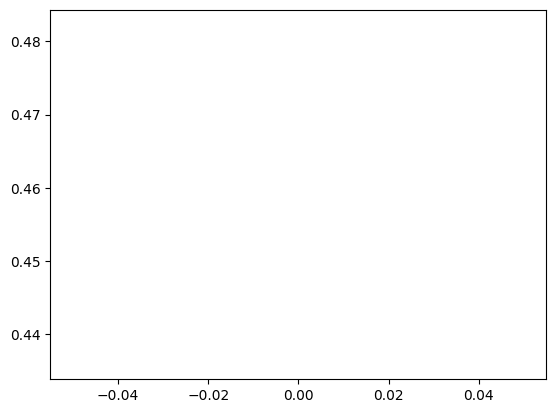

In [6]:
# multiprocessing 
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 4
n = 10
num_runs = 11
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for eps_val in params:
    for _ in range(num_runs):
        tasks.append((init_bandit_ns, n, eps_val, num_steps, step_size))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(run_ns_bandit_cnst_step, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_cnst_stp = np.mean(all_rewards, axis=1)
avg_optimal_cnst_stp = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_cnst_stp_params = np.mean(avg_rewards_cnst_stp[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_cnst_stp_params)
plt.plot(avg_rewards_cnst_stp[5,::10])